In [1]:
import matplotlib.pyplot as plt
import pandas as pd

## Donut Charts - RQ2.3 Analysis

Creating single combined nested donut for RQ2.3...


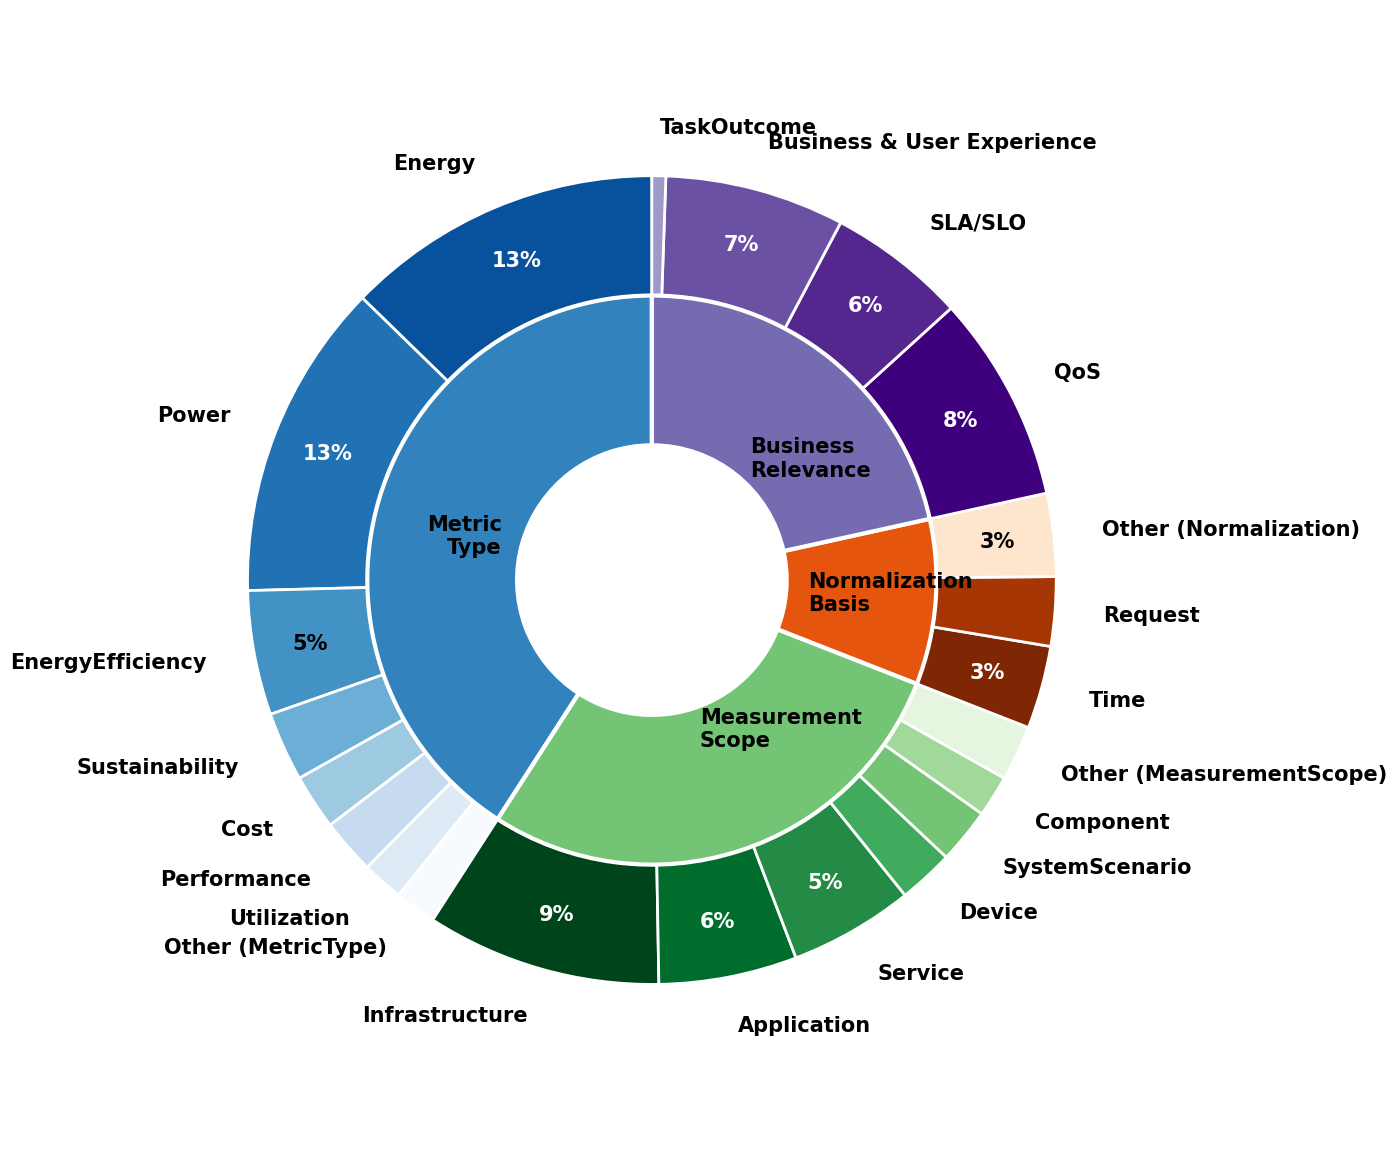

✓ Combined nested donut saved to: output/rq2.3_nested_combined.pdf

=== Summary ===

Single Nested Donut - RQ2.3 Combined Characteristics:
  Metric Type: 74 classifications
  Measurement Scope: 51 classifications
  Normalization Basis: 17 classifications
  Business Relevance: 39 classifications
  Note: Cost and UserExperience are combined into 'Business & User Experience'

✓ Items with count ≤ 2 are grouped into 'Other' for all dimensions except Business Relevance


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Create output directory if it doesn't exist
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

print("Creating single combined nested donut for RQ2.3...")

# Inner ring: four high-level parameters
inner_labels = ['Metric\nType', 'Measurement\nScope', 'Normalization\nBasis', 'Business\nRelevance']
inner_sizes = [74, 51, 17, 39]
inner_colors = ['#3182bd', '#74c476', '#e6550d', '#756bb1']

# Base data for outer ring
metric_type_labels = [
    'Energy', 'Power', 'EnergyEfficiency', 'Sustainability',
    'Cost', 'Performance', 'Utilization', 'EnergyRate', 'DerivedScore'
]
metric_type_sizes = [23, 23, 9, 5, 4, 4, 3, 2, 1]
metric_type_palette = ['#08519c', '#2171b5', '#4292c6', '#6baed6', '#9ecae1', '#c6dbef', '#deebf7', '#eff3ff', '#f7fbff']

scope_labels = [
    'Infrastructure', 'Application', 'Service', 'Device',
    'SystemScenario', 'Component', 'Cluster', 'Network'
]
scope_sizes = [17, 10, 9, 4, 4, 3, 2, 2]
scope_palette = ['#00441b', '#006d2c', '#238b45', '#41ab5d', '#74c476', '#a1d99b', '#c7e9c0', '#e5f5e0']

normalization_labels = [
    'Time', 'Request', 'CPUUtilization', 'Coverage',
    'Execution', 'LinkUtilization', 'Power', 'Scenario'
]
normalization_sizes = [6, 5, 1, 1, 1, 1, 1, 1]
normalization_palette = ['#7f2704', '#a63603', '#d94801', '#f16913', '#fd8d3c', '#fdae6b', '#fdd0a2', '#fee6ce']

# Business Relevance: combine Cost + UserExperience into one category
business_labels = ['QoS', 'SLA/SLO', 'Business & User Experience', 'TaskOutcome']
business_sizes = [15, 10, 13, 1]
business_palette = ['#3f007d', '#54278f', '#6a51a3', '#9e9ac8']


def collapse_small_items(labels, sizes, palette, threshold, other_label):
    kept_labels = []
    kept_sizes = []
    kept_colors = []
    other_total = 0

    for label, size, color in zip(labels, sizes, palette):
        if size <= threshold:
            other_total += size
        else:
            kept_labels.append(label)
            kept_sizes.append(size)
            kept_colors.append(color)

    if other_total > 0:
        kept_labels.append(other_label)
        kept_sizes.append(other_total)
        kept_colors.append(palette[-1])

    return kept_labels, kept_sizes, kept_colors


threshold = 2

metric_labels_c, metric_sizes_c, metric_colors_c = collapse_small_items(
    metric_type_labels, metric_type_sizes, metric_type_palette, threshold, 'Other (MetricType)'
)
scope_labels_c, scope_sizes_c, scope_colors_c = collapse_small_items(
    scope_labels, scope_sizes, scope_palette, threshold, 'Other (MeasurementScope)'
)
norm_labels_c, norm_sizes_c, norm_colors_c = collapse_small_items(
    normalization_labels, normalization_sizes, normalization_palette, threshold, 'Other (Normalization)'
)
# Keep Business Relevance fully explicit (no 'Other' bucket)
business_labels_c, business_sizes_c, business_colors_c = business_labels, business_sizes, business_palette

# Outer ring: collapsed subcategories grouped in the same order as inner ring
outer_labels = metric_labels_c + scope_labels_c + norm_labels_c + business_labels_c
outer_sizes = metric_sizes_c + scope_sizes_c + norm_sizes_c + business_sizes_c
outer_colors = metric_colors_c + scope_colors_c + norm_colors_c + business_colors_c


def pct_if_large(pct):
    return f'{pct:.0f}%' if pct >= 3 else ''


def is_dark_color(rgba, threshold=0.5):
    r, g, b, _ = rgba
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return luminance < threshold


fig, ax = plt.subplots(figsize=(14, 12))

# Outer ring: all subcategories
wedges_outer, _, autotexts_outer = ax.pie(
    outer_sizes,
    labels=outer_labels,
    autopct=pct_if_large,
    radius=1.35,
    colors=outer_colors,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 15, 'fontweight': 'bold'},
    pctdistance=0.86,
    labeldistance=1.12,
    startangle=90
)

# Make percentage text white on dark wedges, black otherwise
for wedge, autotext in zip(wedges_outer, autotexts_outer):
    if autotext.get_text().strip():
        autotext.set_color('white' if is_dark_color(wedge.get_facecolor()) else 'black')
        autotext.set_fontweight('bold')

# Inner ring: high-level parameters
ax.pie(
    inner_sizes,
    labels=inner_labels,
    radius=0.95,
    colors=inner_colors,
    wedgeprops={'width': 0.5, 'edgecolor': 'white', 'linewidth': 3},
    textprops={'fontsize': 15, 'fontweight': 'bold'},
    labeldistance=0.55,
    startangle=90
)

ax.axis('equal')
plt.tight_layout()

combined_path = os.path.join(output_dir, 'rq2.3_nested_combined.pdf')
fig.savefig(combined_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f"✓ Combined nested donut saved to: {combined_path}")
print("\n=== Summary ===\n")
print("Single Nested Donut - RQ2.3 Combined Characteristics:")
print(f"  Metric Type: {inner_sizes[0]} classifications")
print(f"  Measurement Scope: {inner_sizes[1]} classifications")
print(f"  Normalization Basis: {inner_sizes[2]} classifications")
print(f"  Business Relevance: {inner_sizes[3]} classifications")
print("  Note: Cost and UserExperience are combined into 'Business & User Experience'")
print(f"\n✓ Items with count ≤ {threshold} are grouped into 'Other' for all dimensions except Business Relevance")